In [1]:
from models.nsf import SplineFlowSummary
import torch

training set size, length slide window, ablation, resimulation, checks. Traini without noise, test on data also with noise, train also with oise, tsest and check if it is better.

In [2]:
def calculate_loss(model, output):
    logdet = 0.0
    for block in model.flow.blocks:
        logdet = logdet + block.block_det

    log_base = 0.5 * output.pow(2).sum(dim=1)
    return (log_base - logdet).mean()

In [20]:
from torch.utils.data import DataLoader
from torch.amp.grad_scaler import GradScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#def train_inn_cond(model, train_dataset, optim, epochs, batch_size=128, shuffle=True):
#    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=shuffle)
#    scaler = GradScaler("cuda", enabled=(device.type == "cuda"))
#
#    loss_history = []
#
#    model.train()
#    for epoch in range(epochs):
#        epoch_loss = 0.0
#
#        for X, theta in train_loader:
#            X = X.to(device)
#            theta = theta.to(device)
#
#            optim.zero_grad()
#
#            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
#                output = model(X, theta)
#                loss = calculate_loss(model, output)
#
#            scaler.scale(loss).backward()
#            scaler.step(optim)
#            scaler.update()
#
#            epoch_loss += loss.item() * X.size(0)
#
#        epoch_loss /= len(train_dataset)
#        loss_history.append(epoch_loss)
#        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}", end="\r")
#
#    print()
#    return loss_history

In [33]:
from tqdm import tqdm

def train_inn_cond(
    model,
    train_dataset,
    test_dataset,
    optim,
    epochs,
    batch_size=128,
    shuffle=True,
    lr_scheduler=None,
):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=shuffle)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    scaler = GradScaler("cuda", enabled=(device.type == "cuda"))

    history = {
        "train_loss": [],
        "test_loss": []
    }

    pbar = tqdm(range(epochs), desc="Training", leave=True)

    for epoch in pbar:
        model.train()
        train_epoch_loss = 0.0

        # ---- TRAIN LOOP ----
        for X, theta in train_loader:
            X = X.to(device)
            theta = theta.to(device)

            optim.zero_grad()

            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                output = model(X, theta)
                loss = calculate_loss(model, output)

            scaler.scale(loss).backward()
            scaler.step(optim)
            scaler.update()

            train_epoch_loss += loss.item() * X.size(0)

        train_epoch_loss /= len(train_dataset)

        # ---- TEST LOOP ----
        model.eval()
        test_epoch_loss = 0.0

        with torch.no_grad():
            for X, theta in test_loader:
                X = X.to(device)
                theta = theta.to(device)

                with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                    output = model(X, theta)
                    loss = calculate_loss(model, output)

                test_epoch_loss += loss.item() * X.size(0)

        test_epoch_loss /= len(test_dataset)

        # ---- LOGGING ----
        history["train_loss"].append(train_epoch_loss)
        history["test_loss"].append(test_epoch_loss)

        pbar.set_postfix(
            train_loss=train_epoch_loss,
            test_loss=test_epoch_loss
        )

        if lr_scheduler is not None:
            lr_scheduler.step()

    return history

In [22]:
import numpy as np
from sklearn.decomposition import PCA

def fit_com_pca(dataset_com, theta_dim=8):
    all_com = np.stack(dataset_com)            # (N, T, 3)
    N, T, D = all_com.shape
    all_com_flat = all_com.reshape(N, T * D)

    pca = PCA(n_components=theta_dim)
    theta_all = pca.fit_transform(all_com_flat)

    theta_mean = theta_all.mean(axis=0)
    theta_std = theta_all.std(axis=0) + 1e-8

    return pca, theta_mean, theta_std

In [23]:
from torch.utils.data import Dataset

class FootComDataset(Dataset):
    def __init__(self, dataset_foot, dataset_com, pca, theta_mean=None, theta_std=None):
        self.dataset_foot = dataset_foot
        self.dataset_com = dataset_com
        self.pca = pca
        self.theta_mean = theta_mean
        self.theta_std = theta_std

    def __len__(self):
        return len(self.dataset_foot)

    def __getitem__(self, idx):
        foot = self.dataset_foot[idx]   # (T, foot_dim)
        com = self.dataset_com[idx]     # (T, 3)

        x = foot.reshape(-1).astype(np.float32)

        theta = self.pca.transform(com.reshape(1, -1))[0].astype(np.float32)

        if self.theta_mean is not None and self.theta_std is not None:
            theta = (theta - self.theta_mean) / self.theta_std

        return torch.tensor(x, dtype=torch.float32), torch.tensor(theta, dtype=torch.float32)

In [24]:
data = np.load("dataset.npz")
print(data)

foot = data["foot"].astype(np.float32)  # (N, T, 6)
com  = data["com"].astype(np.float32)   # (N, T, 3)
height = data["height"].astype(np.float32)  # (N, 1)    

NpzFile 'dataset.npz' with keys: foot, com, height


In [25]:
import numpy as np

all_com = np.stack(com)  # (N, T, 3)

print("Shape:", all_com.shape)
print("Min:", all_com.min())
print("Max:", all_com.max())
print("Mean:", all_com.mean())
print("Std:", all_com.std())

Shape: (100000, 39, 3)
Min: -3.0890772
Max: 3.3797088
Mean: 0.55238515
Std: 0.82713753


In [9]:
std_across_samples = all_com.std(axis=0)   # (T, 3)

print("Mean std over time:", std_across_samples.mean())

Mean std over time: 0.42882675


In [10]:
print("Foot shape:", foot.shape)
print("COM shape:", com.shape)
print("Height shape:", height.shape)

Foot shape: (100000, 39, 6)
COM shape: (100000, 39, 3)
Height shape: (100000,)


In [26]:
from sklearn.model_selection import train_test_split

foot_train, foot_test, com_train, com_test = train_test_split(
    foot,
    com,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

In [27]:
theta_dim = 8
pca, theta_mean, theta_std = fit_com_pca(com_train, theta_dim=theta_dim)

In [28]:
train_dataset = FootComDataset(
    dataset_foot=foot_train,
    dataset_com=com_train,
    pca=pca,
    theta_mean=theta_mean,
    theta_std=theta_std,
)

In [31]:
test_dataset = FootComDataset(
    dataset_foot=foot_test,
    dataset_com=com_test,
    pca=pca,
    theta_mean=theta_mean,
    theta_std=theta_std,
)

In [11]:
thetas = train_dataset.dataset_com

In [12]:
print("Theta min:", thetas.min(), "Theta max:", thetas.max())

Theta min: -3.0890772 Theta max: 3.3797088


In [16]:
print("CoM min:", com.min(), "CoM max:", com.max())
print("CoM std:", com.std())

CoM min: -3.0890772 CoM max: 3.3797088
CoM std: 0.82713753


In [29]:
T = train_dataset.dataset_foot[0].shape[0]
foot_dim = train_dataset.dataset_foot[0].shape[1]
foot_input_size = T * foot_dim

model = SplineFlowSummary(
    foot_input_size=foot_input_size,
    theta_dim=theta_dim,
    condition_size=16,
    s_hidden=512,
    s_layers=4,
    f_hidden=256,
    f_blocks=3,
    num_bins=8,
    tail_bound=10.0,
).to(device)

In [30]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [34]:
loss_history = train_inn_cond(
    model=model,
    train_dataset=train_dataset,
    test_dataset= test_dataset,
    optim=optimizer,
    epochs=50,
    batch_size=64,
)

Training:   0%|          | 0/50 [00:00<?, ?it/s]

Training: 100%|██████████| 50/50 [49:57<00:00, 59.95s/it, test_loss=-15.2, train_loss=-14.8]


trains, is really slow. would check that it is meaningful and let train. need to get info to be able to plot losses (like david). wpould think about lr schedule

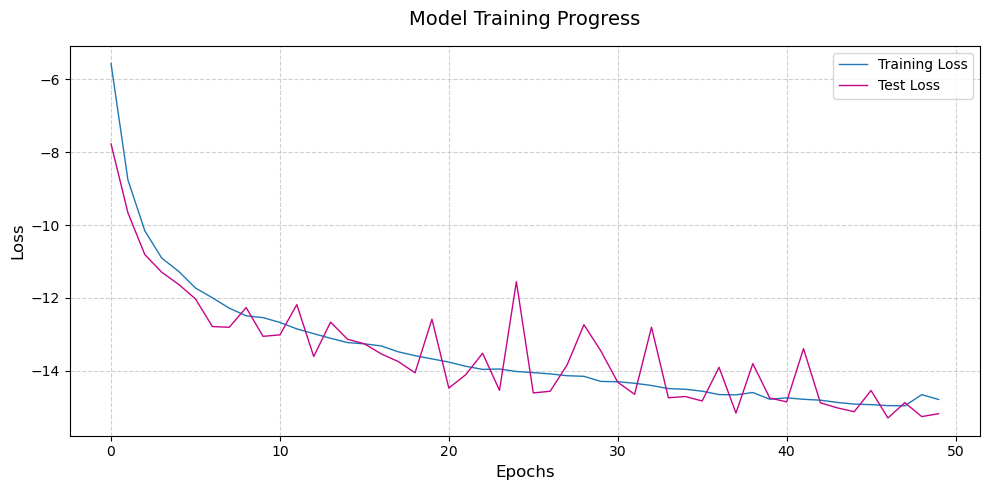

In [ ]:
import matplotlib.pyplot as plt
model.to(device)
model.eval()
# 1. Set a clean style
plt.style.use('seaborn-v0_8-muted') # or 'ggplot'
plt.figure(figsize=(10, 5), dpi=100)

# 2. Plot with better aesthetics
plt.plot(np.array(loss_history["train_loss"][:]), 
         color='#1f77b4',       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Training Loss')

plt.plot(np.array(loss_history["test_loss"][:]), 
         color="#c50488",       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Test Loss')


# 3. Add context and labels
plt.title('Model Training Progress', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# 4. Clean up the "frame"
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

In [37]:
def compute_mmd(x, y, sigma=1.0):
    """
    Computes the Maximum Mean Discrepancy (MMD) between two sets of samples.
    Args:
        x: Tensor of shape [n, d] (Samples from Distribution P)
        y: Tensor of shape [m, d] (Samples from Distribution Q)
        sigma: Bandwidth of the RBF kernel
    """
    # 1. Compute distance matrix (n+m, n+m)
    z = torch.cat([x, y], dim=0)
    # Efficient pairwise distance calculation: ||a-b||^2 = ||a||^2 + ||b||^2 - 2<a,b>
    dist_matrix = torch.cdist(z, z, p=2)**2
    
    # 2. Apply Gaussian Kernel
    kernel_matrix = torch.exp(-dist_matrix / (2 * sigma**2))
    
    # 3. Extract sub-matrices
    n = x.size(0)
    m = y.size(0)
    
    k_xx = kernel_matrix[:n, :n]
    k_yy = kernel_matrix[n:, n:]
    k_xy = kernel_matrix[:n, n:]
    
    # 4. Compute MMD^2 (Unbiased estimator)
    # Subtracting the diagonal (self-distances) for k_xx and k_yy
    mmd2 = (k_xx.sum() - n) / (n * (n - 1)) + \
           (k_yy.sum() - m) / (m * (m - 1)) - \
           2 * k_xy.mean()
           
    return mmd2

Train latent std per dim:
 tensor([0.9337, 0.9309, 0.9664, 0.9237, 0.8791, 0.7717, 0.9878, 0.7667])
Train latent covariance:
 tensor([[ 0.8718,  0.0463, -0.0304, -0.0036,  0.0606, -0.0217, -0.0422,  0.1389],
        [ 0.0463,  0.8666, -0.0390, -0.1105,  0.1695, -0.0324,  0.0879,  0.1242],
        [-0.0304, -0.0390,  0.9340,  0.0733, -0.1243,  0.0442,  0.0062, -0.1459],
        [-0.0036, -0.1105,  0.0733,  0.8533, -0.1145,  0.0829, -0.0775,  0.1162],
        [ 0.0606,  0.1695, -0.1243, -0.1145,  0.7729, -0.0619, -0.0378,  0.0065],
        [-0.0217, -0.0324,  0.0442,  0.0829, -0.0619,  0.5955, -0.0081,  0.0142],
        [-0.0422,  0.0879,  0.0062, -0.0775, -0.0378, -0.0081,  0.9757,  0.1008],
        [ 0.1389,  0.1242, -0.1459,  0.1162,  0.0065,  0.0142,  0.1008,  0.5878]])


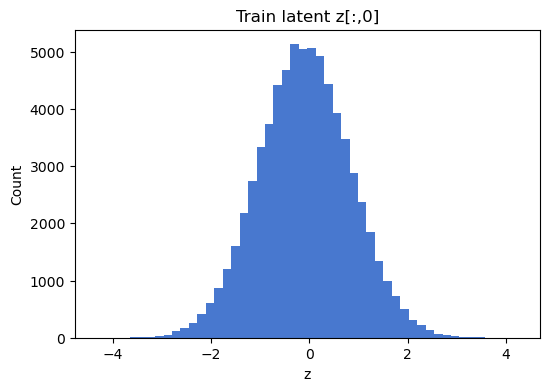

In [40]:
train_tensor_foot = torch.stack([x for x, _ in train_dataset])
train_theta_pca   = torch.stack([theta for _, theta in train_dataset])

test_tensor_foot = torch.stack([x for x, _ in test_dataset])
test_theta_pca   = torch.stack([theta for _, theta in test_dataset])

with torch.no_grad():
    z_train = model(
        train_tensor_foot.to(device),
        train_theta_pca.to(device)
    ).cpu()

print("Train latent std per dim:\n", z_train.std(0))
print("Train latent covariance:\n", torch.cov(z_train.T))

plt.figure(figsize=(6,4))
plt.hist(z_train[:, 0].numpy(), bins=50)
plt.title("Train latent z[:,0]")
plt.xlabel("z")
plt.ylabel("Count")
plt.show()

Test latent std per dim:
 tensor([0.9417, 0.9416, 0.9752, 0.9271, 0.8831, 0.7826, 1.0066, 0.7761])


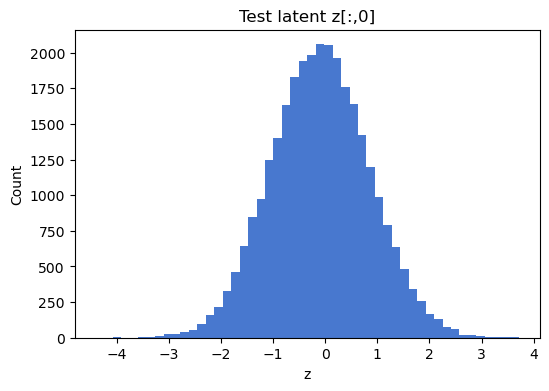

In [41]:
with torch.no_grad():
    z_test = model(
        test_tensor_foot.to(device),
        test_theta_pca.to(device)
    ).cpu()

print("Test latent std per dim:\n", z_test.std(0))

plt.figure(figsize=(6,4))
plt.hist(z_test[:, 0].numpy(), bins=50)
plt.title("Test latent z[:,0]")
plt.xlabel("z")
plt.ylabel("Count")
plt.show()

In [45]:
n_real = 50
n_per_real = 200
theta_dim = train_theta_pca.shape[1]
T = 39
coord_dim = 3

foot_data = test_tensor_foot[:n_real].to(device)

z = torch.randn(n_real * n_per_real, theta_dim, device=device)

# sample from posterior
with torch.no_grad():
    theta_samples = model.reverse(
        z=z,
        x=foot_data.repeat_interleave(n_per_real, dim=0)
    ).cpu().numpy()

theta_samples = theta_samples.reshape(n_real, n_per_real, theta_dim)
theta_truth = test_theta_pca[:n_real].cpu().numpy()

theta_samples_pca = theta_samples * theta_std + theta_mean
theta_truth_pca   = theta_truth * theta_std + theta_mean

# inverse pca to get com trajectories
decoded_samples = pca.inverse_transform(
    theta_samples_pca.reshape(-1, theta_dim)
).reshape(n_real, n_per_real, T, coord_dim)

decoded_truth = pca.inverse_transform(
    theta_truth_pca
).reshape(n_real, T, coord_dim)

forward direction (x)

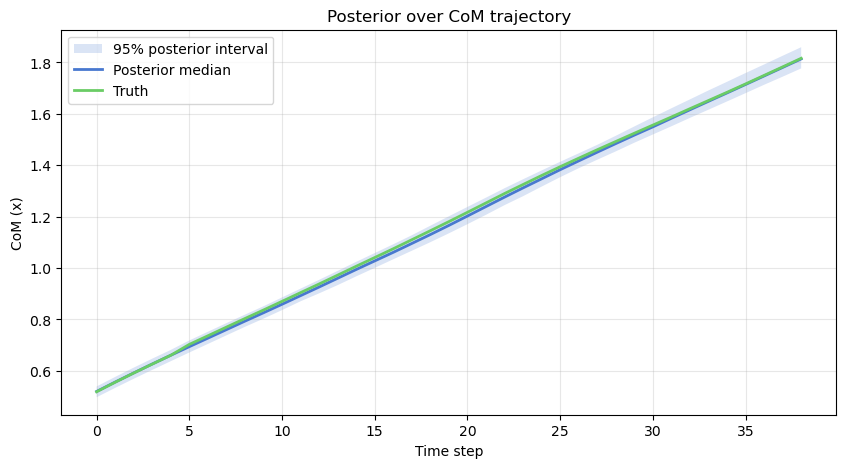

In [46]:
import matplotlib.pyplot as plt
import numpy as np

sample_idx = 0   # choose one test example
coord_idx = 0    # 0=x, 1=y, 2=z

traj_samples = decoded_samples[sample_idx, :, :, coord_idx]   # (n_per_real, T)
traj_truth = decoded_truth[sample_idx, :, coord_idx]          # (T,)

# compute quantiles
lower = np.percentile(traj_samples, 2.5, axis=0)
median = np.percentile(traj_samples, 50, axis=0)
upper = np.percentile(traj_samples, 97.5, axis=0)

time = np.arange(T)

plt.figure(figsize=(10,5))
plt.fill_between(time, lower, upper, alpha=0.2, label="95% posterior interval")
plt.plot(time, median, lw=2, label="Posterior median")
plt.plot(time, traj_truth, lw=2, label="Truth")

plt.xlabel("Time step")
plt.ylabel("CoM (x)")
plt.title("Posterior over CoM trajectory")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

vertical direction (y)

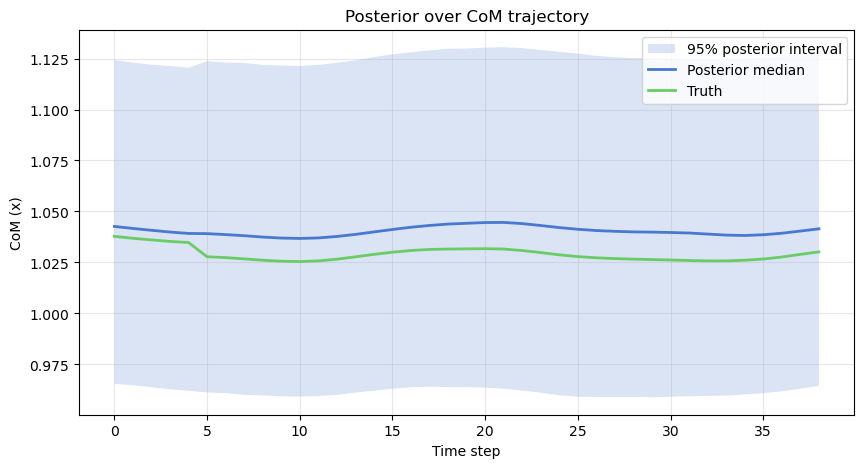

In [48]:
import matplotlib.pyplot as plt
import numpy as np

sample_idx = 0   # choose one test example
coord_idx = 1    # 0=x, 1=y, 2=z

traj_samples = decoded_samples[sample_idx, :, :, coord_idx]   # (n_per_real, T)
traj_truth = decoded_truth[sample_idx, :, coord_idx]          # (T,)

# compute quantiles
lower = np.percentile(traj_samples, 2.5, axis=0)
median = np.percentile(traj_samples, 50, axis=0)
upper = np.percentile(traj_samples, 97.5, axis=0)

time = np.arange(T)

plt.figure(figsize=(10,5))
plt.fill_between(time, lower, upper, alpha=0.2, label="95% posterior interval")
plt.plot(time, median, lw=2, label="Posterior median")
plt.plot(time, traj_truth, lw=2, label="Truth")

plt.xlabel("Time step")
plt.ylabel("CoM (x)")
plt.title("Posterior over CoM trajectory")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

lateral direction (z)

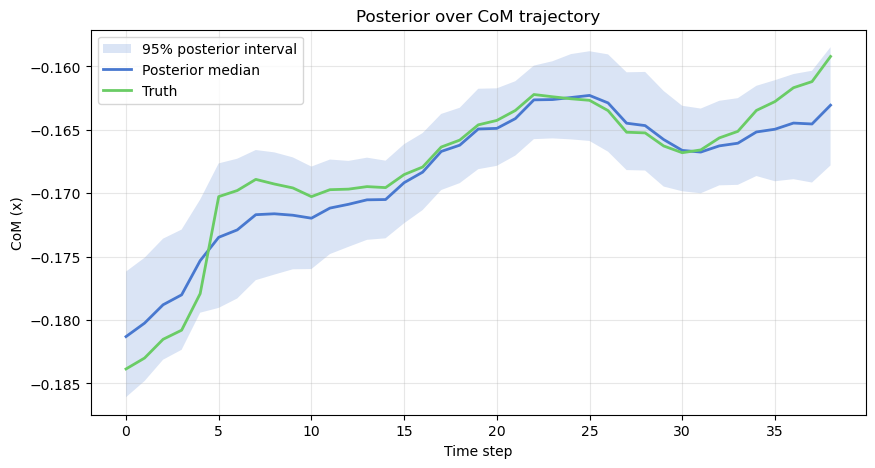

In [49]:
import matplotlib.pyplot as plt
import numpy as np

sample_idx = 0   # test example
coord_idx = 2    
traj_samples = decoded_samples[sample_idx, :, :, coord_idx]   # (n_per_real, T)
traj_truth = decoded_truth[sample_idx, :, coord_idx]          # (T,)

# compute quantiles
lower = np.percentile(traj_samples, 2.5, axis=0)
median = np.percentile(traj_samples, 50, axis=0)
upper = np.percentile(traj_samples, 97.5, axis=0)

time = np.arange(T)

plt.figure(figsize=(10,5))
plt.fill_between(time, lower, upper, alpha=0.2, label="95% posterior interval")
plt.plot(time, median, lw=2, label="Posterior median")
plt.plot(time, traj_truth, lw=2, label="Truth")

plt.xlabel("Time step")
plt.ylabel("CoM (x)")
plt.title("Posterior over CoM trajectory")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

i think it looks really wierd because of the pca and not training for a long time. Training + windows of foot positions of pca today.